# **Apprentissage du Pricing d'Options (BSM)**
## **Étude comparative : Réseau Standard vs Sobolev vs PINNs**


Ce projet compare l'efficacité de trois architectures (MLP standard, Sobolev Training, PINNs) pour l'approximation de la formule de Black-Scholes. L'objectif est de démontrer que l'apprentissage des dérivées (Greeks) accélère la convergence et améliore la couverture (Hedging).

Ce projet sert de prototyte, en effet si l'apprentissage du prix sur des options européennes par des réseaux de neurones paraît inutile, ces techniques peuvent s'avérer critiques dans le cas de dérivés plus complexes faisant intervenir des simulations types Monte-Carlo.

Je me suis notamment inspiré de l'article d'Antoine Savine "Differential Machine Learning" pour la réalisation de ce notebook.

## **1. Génération des données**

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt
import random

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

On rappelle la formule du prix d'un call dans le modèle BSM :
$$
C(S, t) = N(d_1)S - N(d_2)Ke^{-r(T-t)}
$$
Où :
$$
d_1 = \frac{\ln(S/K) + (r + \frac{\sigma^2}{2})(T-t)}{\sigma\sqrt{T-t}}
$$

In [12]:
# ==========================================
# 1. Formule de Black-Scholes
# ==========================================
def black_scholes_call(S, K, T, r, sigma):
    """
    Calcule le prix théorique d'un Call Européen.
    """

    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = (S * si.norm.cdf(d1, 0.0, 1.0) -
                  K * np.exp(-r * T) * si.norm.cdf(d2, 0.0, 1.0))

    # Delta du Call : Delta = N(d1)
    delta = si.norm.cdf(d1)

    return call_price, delta

In [13]:
# ==========================================
# 2. Génération des Données d'Entraînement
# ==========================================
def generate_data(n_samples=10000):
    """
    Génère des données aléatoires de marché et calcule les prix correspondants.
    """
    # S (Spot) : Entre 50 et 150
    S = np.random.uniform(50, 150, n_samples)
    # K (Strike) : Entre 50 et 150
    K = np.random.uniform(50, 150, n_samples)
    # T (Maturité) : Entre 0.1 an et 2 ans
    T = np.random.uniform(0.1, 2.0, n_samples)
    # r (Taux) : Entre 1% et 5%
    r = np.random.uniform(0.01, 0.05, n_samples)
    # sigma (Volatilité) : Entre 10% et 50%
    sigma = np.random.uniform(0.1, 0.5, n_samples)

    # Calcul des cibles (Prix réels et deltas)
    prices, deltas = black_scholes_call(S, K, T, r, sigma)


    # Normalisation
    X = np.stack([S/100.0, K/100.0, T, r, sigma], axis=1)
    y = prices.reshape(-1, 1) / 100
    dy = deltas.reshape(-1, 1)

    # Conversion en tenseurs PyTorch (float32)
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(dy, dtype=torch.float32))



## **2. Conception et entrainement**

In [14]:
# ==========================================
# 3. L'Architecture du Réseau
# ==========================================
class PricingModel(nn.Module):
    def __init__(self, input_dim=5):
        super(PricingModel, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LayerNorm(64), # Plus stable que BatchNorm pour les calculs de gradients
            nn.Tanh(),          # Indispensable pour avoir des dérivées (Grecs) lisses

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

L'approche proposé par A. Savine intègre à la fonction de coût les erreurs sur les gradients et permet d'avoir une surface des prix plus lisse.

$$
\mathcal{L}_{Sobolev} = \underbrace{\frac{1}{N}\sum_{i=1}^N (V_{pred}^{(i)} - V_{target}^{(i)})^2}_{\text{MSE Prix}} + \lambda \underbrace{\frac{1}{N}\sum_{i=1}^N \left(\frac{\partial V_{pred}}{\partial S}\bigg|_i - \Delta_{BS}^{(i)}\right)^2}_{\text{MSE Delta}}
$$

In [15]:
def sobolev_loss(
    model: nn.Module,
    inputs: torch.Tensor,
    target_price: torch.Tensor,
    target_delta: torch.Tensor,
    lmbda: float = 1.0
) -> tuple[torch.Tensor, dict]:

    inputs.requires_grad_(True)
    pred_price = model(inputs)

    # 1. Gradient par rapport à l'entrée normalisée
    grads = torch.autograd.grad(pred_price.sum(), inputs, create_graph=True)[0]
    grad_S_norm = grads[:, 0:1]


    mse_price = nn.MSELoss()(pred_price, target_price)

    # On compare des pommes avec des pommes (Delta physique vs Delta cible)
    mse_delta = nn.MSELoss()(grad_S_norm, target_delta)

    return mse_price + lmbda * mse_delta

On propose une troisième approche "PINNs" (Physical Informed Neural Network) où on intègre l'équation partiel de BSM à la fonction perte.

$$
\mathcal{L}_{PINN} = \mathcal{L}_{Data} + \mu \cdot \mathcal{L}_{PDE}
$$
Avec le résidu physique :
$$
\mathcal{L}_{PDE} = \frac{1}{N}\sum \left( -\frac{\partial \hat{V}}{\partial \tau} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 \hat{V}}{\partial S^2} + rS \frac{\partial \hat{V}}{\partial S} - r\hat{V} \right)^2
$$

In [16]:
def pinn_loss(
    model: nn.Module,
    inputs: torch.Tensor,
    target_price: torch.Tensor,
    mu: float = 0.1,
) -> tuple[torch.Tensor, dict]:

    inputs.requires_grad_(True)

    # 1. Récupération des inputs normalisés
    S_norm = inputs[:, 0:1]

    # 2. Prédiction (Prix normalisé)
    pred_price_norm = model(inputs)

    # 3. Calcul des gradients sur le monde normalisé
    grads = torch.autograd.grad(pred_price_norm.sum(), inputs, create_graph=True)[0]
    delta_pred = grads[:, 0:1] # d(P_norm)/d(S_norm) = Delta réel
    theta_pred_norm = grads[:, 2:3] # d(P_norm)/d(T)

    # Dérivée seconde (Gamma)
    # Gamma réel = d(Delta)/dS_phys = d(Delta)/d(S_norm * 100) = (1/100) * d(Delta)/d(S_norm)
    grad_delta = torch.autograd.grad(delta_pred.sum(), inputs, create_graph=True)[0]
    gamma_pred_norm = grad_delta[:, 0:1]

    # 4. PASSAGE AU MONDE PHYSIQUE pour l'équation
    # On remet tout à l'échelle pour que Black-Scholes fonctionne
    S_phys = S_norm * 100.0
    P_phys = pred_price_norm * 100.0

    # Delta est sans unité, il reste tel quel
    Delta_phys = delta_pred

    # Gamma a pour unité Price/S^2.
    # Avec notre normalisation : Gamma_phys = Gamma_output / 100.0
    Gamma_phys = gamma_pred_norm / 100.0

    # Theta a pour unité Price/Time.
    # Theta_phys = Theta_output * 100.0
    Theta_phys = theta_pred_norm * 100.0

    # Paramètres
    r = inputs[:, 3:4]     # r est en colonne 3
    sigma = inputs[:, 4:5] # sigma est en colonne 4

    # Équation de Black-Scholes (tous les termes en unités monétaires réelles)
    # dC/dt + 0.5*sigma^2*S^2*Gamma + r*S*Delta - r*C = 0
    # Note : inputs[:, 2] est T (maturité). Donc dC/dt = - dC/dT
    pde_residual = -Theta_phys + 0.5 * (sigma**2) * (S_phys**2) * Gamma_phys + r * S_phys * Delta_phys - r * P_phys

    mse_price = nn.MSELoss()(pred_price_norm, target_price)
    mse_pde = torch.mean(pde_residual**2)

    # On normalise le résidu PDE pour qu'il ne soit pas trop grand face au MSE
    # (Division par 100^2 car c'est une erreur au carré sur des prix non normalisés)
    return mse_price + mu * (mse_pde / 10000.0)

In [17]:
# ==========================================
# 4. Entraînement
# ==========================================
def train_model(
    mode: str = 'standard',
    n_epochs: int = 20
    ) -> nn.Module:

    model = PricingModel()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Pour Standard, on garde le MSE simple
    base_criterion = nn.MSELoss()
    batch_size = 128

    print(f"--- Entraînement Mode: {mode.upper()} ---")



    for epoch in range(n_epochs):
        model.train()
        permutation = torch.randperm(X_train.size()[0])

        for i in range(0, X_train.size()[0], batch_size):
            indices = permutation[i:i+batch_size]
            batch_x = X_train[indices].clone().detach().requires_grad_(True)
            batch_y = y_train[indices]
            batch_delta = delta_train[indices]

            optimizer.zero_grad()

            if mode == 'standard':
                outputs = model(batch_x)
                loss = base_criterion(outputs, batch_y)

            elif mode == 'sobolev':
                # Appel de la fonction sobolev_loss définie précédemment
                loss = sobolev_loss(model, batch_x, batch_y, batch_delta, lmbda=1)

            elif mode == 'pinn':
                # Appel de la fonction pinn_loss définie précédemment
                loss = pinn_loss(model, batch_x, batch_y, mu=1)

            loss.backward()
            optimizer.step()

        # Évaluation (Validation)
        if (epoch+1) % 5 == 0:
            model.eval()
            with torch.no_grad(): # Pas besoin de gradients pour la validation standard
                val_preds = model(X_val)
                val_loss = base_criterion(val_preds, y_val)
                print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.6f}, Val MSE: {val_loss.item():.6f}')

    return model

# On génère aussi les deltas réels pour Sobolev
X_train, y_train, delta_train = generate_data(n_samples=1000)
X_val, y_val, delta_val = generate_data(n_samples=2000)

model_std = train_model(mode='standard')
model_sob = train_model(mode='sobolev')
model_pinn = train_model(mode='pinn')

--- Entraînement Mode: STANDARD ---
Epoch [5/20], Loss: 0.010684, Val MSE: 0.009660
Epoch [10/20], Loss: 0.007888, Val MSE: 0.007563
Epoch [15/20], Loss: 0.006123, Val MSE: 0.005701
Epoch [20/20], Loss: 0.003443, Val MSE: 0.004120
--- Entraînement Mode: SOBOLEV ---
Epoch [5/20], Loss: 0.075940, Val MSE: 0.007166
Epoch [10/20], Loss: 0.014264, Val MSE: 0.001447
Epoch [15/20], Loss: 0.017411, Val MSE: 0.001121
Epoch [20/20], Loss: 0.008662, Val MSE: 0.000734
--- Entraînement Mode: PINN ---
Epoch [5/20], Loss: 0.010176, Val MSE: 0.010864
Epoch [10/20], Loss: 0.009837, Val MSE: 0.008021
Epoch [15/20], Loss: 0.005843, Val MSE: 0.005735
Epoch [20/20], Loss: 0.003564, Val MSE: 0.003456


## **3. Prédictions et représentation graphique**

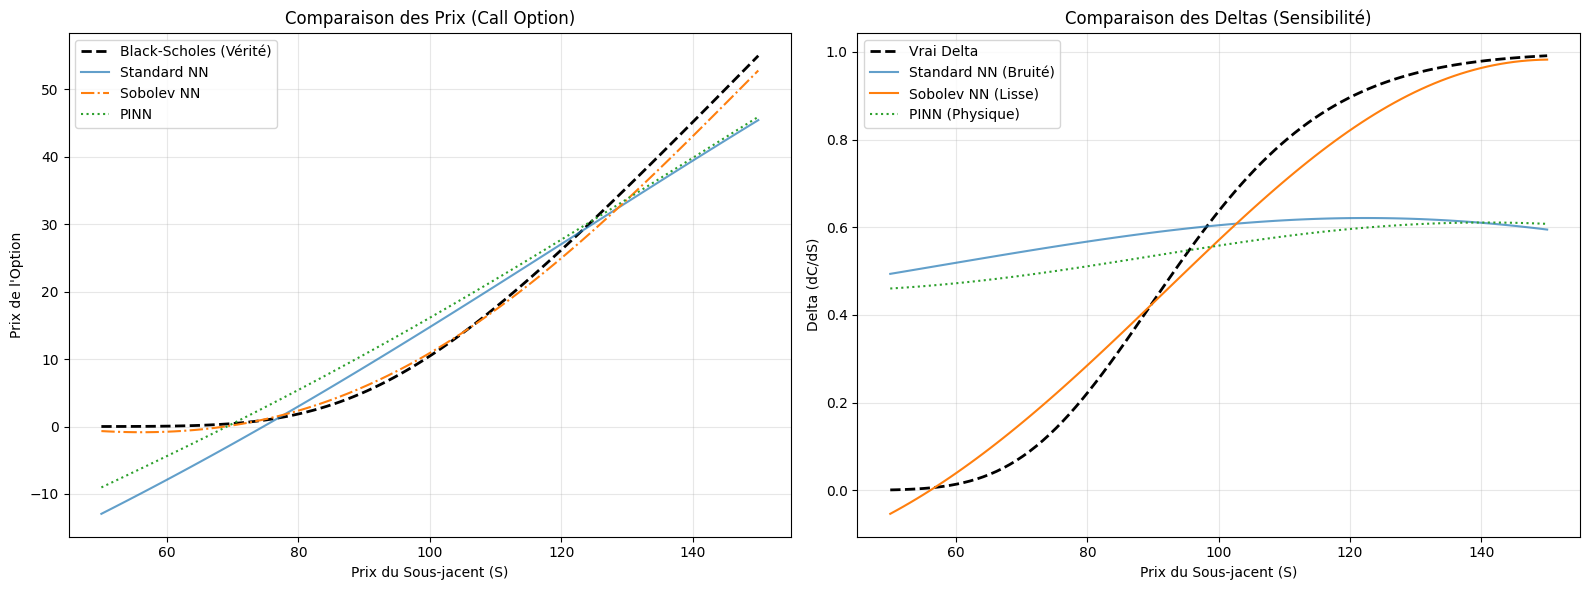

RMSE Standard NN sur les prix: 24.611656921175374 et sur les deltas: 0.38108744296192015
RMSE Sobolev NN sur les prix: 24.15001078142067 et sur les deltas: 0.5109787262207115
RMSE PINN: 23.77259258503306 sur les prix et sur les deltas: 0.3811886005905138


In [18]:
def predict_price_and_delta(model, X_tensor):
    """
    Retourne le prix et le delta (gradient) pour un modèle donné.
    """
    model.eval()
    # On clone pour ne pas modifier le tenseur original et on active le gradient
    X = X_tensor.clone().detach().requires_grad_(True)

    # 1. Prédiction du prix
    price_pred = model(X)

    # 2. Calcul du gradient (Delta)
    # On veut d(Prix)/d(Input_S)
    grads = torch.autograd.grad(price_pred.sum(), X, create_graph=False)[0]

    # Attention : L'entrée S a été divisée par 100 dans le preprocessing.
    # Mathématiquement : dC/dS = (dC/dX) * (dX/dS) = grad * (1/100)
    # Pour la comparaison visuelle, on prend le gradient brut de la 1ère colonne (S)
    delta_pred = grads[:, 0:1]

    return price_pred.detach().numpy()*100, delta_pred.detach().numpy()

# --- Paramètres du scénario ---
n_test = 100
S_vals = np.linspace(50, 150, n_test) # S varie
K_val = 100.0                         # Strike fixe
T_val = 1.0                           # 1 an maturité
r_val = 0.05                          # 5% taux
sigma_val = 0.2                       # 20% vol

# --- Préparation du tenseur d'entrée ---
# On respecte la même normalisation que l'entraînement !
# Rappel : S/100, K/100, T, r, sigma
X_test_np = np.stack([
    S_vals / 100.0,
    np.full(n_test, K_val) / 100.0,
    np.full(n_test, T_val),
    np.full(n_test, r_val),
    np.full(n_test, sigma_val)
], axis=1)

X_test_torch = torch.tensor(X_test_np, dtype=torch.float32)

# --- Vérité Terrain (Black-Scholes Analytique) ---
true_prices, true_deltas = black_scholes_call(
    S_vals,
    np.full(n_test, K_val),
    np.full(n_test, T_val),
    np.full(n_test, r_val),
    np.full(n_test, sigma_val)
)


# 1. Récupération des prédictions
price_std, delta_std = predict_price_and_delta(model_std, X_test_torch)
price_sob, delta_sob = predict_price_and_delta(model_sob, X_test_torch)
price_pinn, delta_pinn = predict_price_and_delta(model_pinn, X_test_torch)

# 2. Affichage
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Les Prix ---
ax[0].plot(S_vals, true_prices, 'k--', label='Black-Scholes (Vérité)', linewidth=2)
ax[0].plot(S_vals, price_std, label='Standard NN', alpha=0.7)
ax[0].plot(S_vals, price_sob, label='Sobolev NN', linestyle='-.')
ax[0].plot(S_vals, price_pinn, label='PINN', linestyle=':')
ax[0].set_title("Comparaison des Prix (Call Option)")
ax[0].set_xlabel("Prix du Sous-jacent (S)")
ax[0].set_ylabel("Prix de l'Option")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# --- Graphique 2 : Les Deltas (La partie cruciale) ---
ax[1].plot(S_vals, true_deltas, 'k--', label='Vrai Delta', linewidth=2)
ax[1].plot(S_vals, delta_std, label='Standard NN (Bruité)', alpha=0.7)
ax[1].plot(S_vals, delta_sob, label='Sobolev NN (Lisse)')
ax[1].plot(S_vals, delta_pinn, label='PINN (Physique)', linestyle=':')

ax[1].set_title("Comparaison des Deltas (Sensibilité)")
ax[1].set_xlabel("Prix du Sous-jacent (S)")
ax[1].set_ylabel("Delta (dC/dS)")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcul RMSE
rmse_std_prices = np.sqrt(np.mean((true_prices - price_std)**2))
rmse_sob_prices = np.sqrt(np.mean((true_prices - price_sob)**2))
rmse_pinn_prices = np.sqrt(np.mean((true_prices - price_pinn)**2))

rmse_std_deltas = np.sqrt(np.mean((true_deltas - delta_std)**2))
rmse_sob_deltas = np.sqrt(np.mean((true_deltas - delta_sob)**2))
rmse_pinn_deltas = np.sqrt(np.mean((true_deltas - delta_pinn)**2))

print(f"RMSE Standard NN sur les prix: {rmse_std_prices} et sur les deltas: {rmse_std_deltas}")
print(f"RMSE Sobolev NN sur les prix: {rmse_sob_prices} et sur les deltas: {rmse_sob_deltas}")
print(f"RMSE PINN: {rmse_pinn_prices} sur les prix et sur les deltas: {rmse_pinn_deltas}")


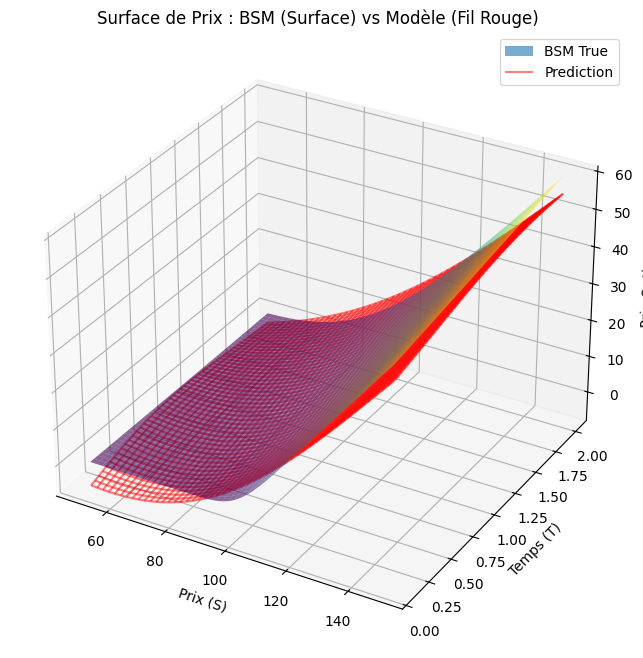

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_price_surface_3d(model=None, plot_truth=True):
    # 1. Création de la grille de points
    S_vals = np.linspace(50, 150, 50)
    T_vals = np.linspace(0.1, 2.0, 50)
    S_grid, T_grid = np.meshgrid(S_vals, T_vals)

    # Paramètres fixes pour la surface
    K_val = 100.0
    r_val = 0.05
    sigma_val = 0.2

    # 2. Préparation de la figure
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 3. Tracé de la Vérité Terrain (Black-Scholes)
    if plot_truth:
        C_true = black_scholes_call(S_grid, K_val, T_grid, r_val, sigma_val)[0] # [0] car la fonction renvoie (prix, delta)
        surf_true = ax.plot_surface(S_grid, T_grid, C_true, cmap='viridis', alpha=0.6, label='BSM True')
        # Hack pour la légende des surfaces
        surf_true._facecolors2d = surf_true._facecolor3d
        surf_true._edgecolors2d = surf_true._edgecolor3d

    # 4. Tracé de la Prédiction du Modèle (Optionnel)
    if model is not None:
        # On doit aplatir la grille pour passer dans le réseau
        # Rappel input: S/100, K/100, T, r, sigma

        # Aplatissement
        S_flat = S_grid.flatten()
        T_flat = T_grid.flatten()
        N = len(S_flat)

        # Construction du tenseur
        X_surf = np.stack([
            S_flat / 100.0,
            np.full(N, K_val) / 100.0,
            T_flat,
            np.full(N, r_val),
            np.full(N, sigma_val)
        ], axis=1)

        X_tensor = torch.tensor(X_surf, dtype=torch.float32)

        # Prédiction
        model.eval()
        with torch.no_grad():
            pred_flat = model(X_tensor).numpy().flatten()

        # Remise à l'échelle (x100 car on a normalisé y)
        pred_grid = pred_flat.reshape(S_grid.shape) * 100.0

        # Tracé de la surface prédite (en rouge fil de fer pour comparer)
        ax.plot_wireframe(S_grid, T_grid, pred_grid, color='red', alpha=0.5, label='Prediction')

    ax.set_title("Surface de Prix : BSM (Surface) vs Modèle (Fil Rouge)")
    ax.set_xlabel("Prix (S)")
    ax.set_ylabel("Temps (T)")
    ax.set_zlabel("Prix Option")
    plt.legend()
    plt.show()

# Utilisation :
plot_price_surface_3d(model=model_sob)
